# FPVS pypeline
###### The purpose of this script is to create an open source platform to process EEG data; similar to the letswave6 application in MATLAB. 
###### Author: Bhargav Pakhare (so far)

#### dependencies
 -> scipi.io     -> matplotlib  -> subprocess    -> ipyml 
 -> pathlib      -> numpy       -> mne           -> pickle
 -> h5py         -> pandas      -> importlib     -> ipython
 -> trimesh

### Wishlist
1. Add functionality to take only those chunks where the signal is significantly greater than the baseline/noise in step 12
2. Understand what does SNR correction do and how to implement it
3. Store the meta data file as a .json file, making it easier when developing an actual application.
4. Add functionality to take in .bdf file as well as .lw6 file in the 0th step
5. In step 0, the fs is assumed to be 2khz, change to make it so that it is calculated. 

### Completed wishlist :
1. Add a history section in the lw6 data that shows all the changes made to that particular file so that one doesnt have to hunt down all previous iterations of the file.      DONE!
2. Create a module for this pipeline where you only have to run a couple of functions to get the final product out DONE!
3. Add functionality for chanlocs and chan labels editing    DONE!
4. Always plot x,y and graph labels                          DONE! 
5. Create an interactive application to preprocess           Done, kind of, all plots are interactive
6. Make topographical maps that are interactive and make the channel locs light up in the topographical map when plotting the ft data.  DONE!
7. Reduce dependablity on MATLAB by changing the format of data from matlab style to python style  DONE!


### Changes I have made: 
1. Downsampling the data has changed its position to make things easier
2. ICA is done before segmentation, just to avoid stitching back data to perform ICA and then breaking it apart again after ICA
3. LW6 data renamed meta data, and the fields are updated to reflect a few fields which are easier to access as compared to matlab
4. meta data now stored as a .pkl file to make

In [ ]:
## UI for datafile selection for when we start with GUI
from ipyfilechooser import FileChooser
fc = FileChooser()
display(fc)
# This will now contain the path string
filepath = (fc.selected)
print(filepath)

## 0. import data files and relevant libraries


In [ ]:
# meta_data.chanlocs.labels
# meta_data["chanlocs"]["labels"]

the keys in old data are:  ('filetype', 'name', 'tags', 'history', 'datasize', 'xstart', 'ystart', 'zstart', 'xstep', 'ystep', 'zstep', 'chanlocs', 'events')
the keys in the new data are:  dict_keys(['filetype', 'name', 'tags', 'history', 'origins', 'datasize', 'xstart', 'ystart', 'zstart', 'xstep', 'ystep', 'zstep', 'chanlocs', 'events', 'fs', 'activation', 'fields'])
D:\Goffaux lab\Data set\second expt\TRSG1512.pkl
data is saved as:  D:\Goffaux lab\Data set\second expt\TRSG1512.pkl


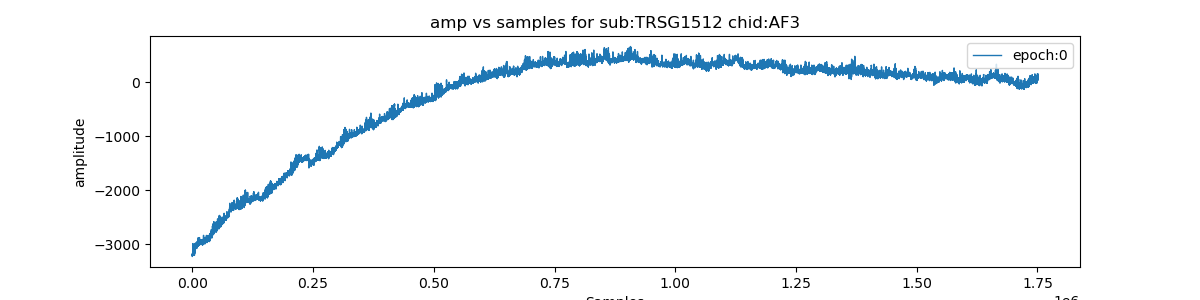

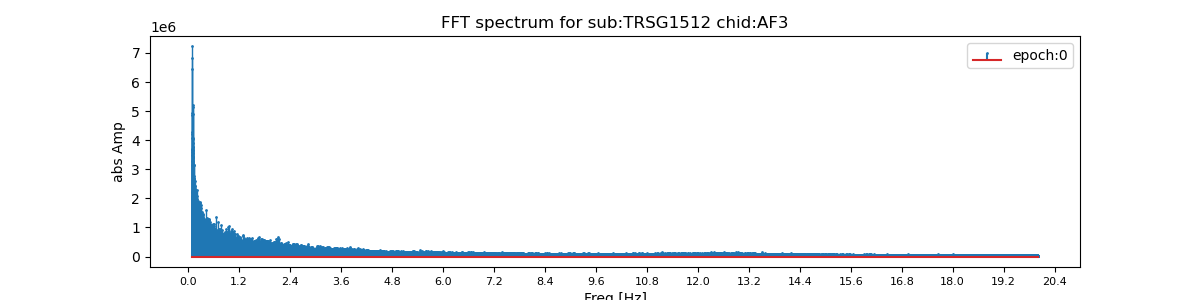

In [1]:
# wish list:
# 1. Add functionality for chanlocs and labels editing in this script

%reset -f
import scipy.io as sci
from pathlib import Path
import h5py
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
import math
from collections import Counter
import importlib
import cust_funcs as cf
importlib.reload(cf)
import ipympl

folderpath=Path("D:\Goffaux lab\Data set\second expt\TRSG1512.mat")
subjid=folderpath.stem
# folderpath=filepath
matfilepath=folderpath.with_suffix(".mat")
lw6filepath=folderpath.with_suffix(".lw6")

# 1. load the file only after altering channel labels
with h5py.File(matfilepath, 'r') as f:
    # List all variables
    mat_data = f['data'][:]

# This section cleans the data and meta data to make it more python friendly
mat_data = np.squeeze(mat_data)
# metafilepath = matfilepath.with_suffix(".pkl")
meta_data = cf.rebrand_lw6data(lw6filepath)
meta_data["fs"] = 512 # only when dealing with the second expt

#renaming the mat/lw6 filenames for saving the intermediary steps.
metafilepath = matfilepath.with_suffix(".pkl")
matfilepath = matfilepath.with_suffix(".npy")

print(metafilepath)
cf.saveMetadata(meta_data,metafilepath)
np.save(matfilepath, mat_data)

print("data is saved as: ", metafilepath)

chid=3
cf.showmeSummaryPlot(mat_data[:,chid-1],fs=np.squeeze(meta_data["fs"]),chname=meta_data["chanlocs"]["labels"][chid-1],subjid=subjid)

## 1. Rename channels

In [2]:
labels  = (meta_data["chanlocs"]["labels"])
targets = ["EXG1", "EXG2", "EXG3", "EXG4"]
replacements = ["I1", "I2", "PO9", "PO10"]
mapping = dict(zip(targets, replacements))
labels = [mapping.get(label, label) for label in labels]
meta_data["chanlocs"]["labels"] = labels

meta_data = cf.updatemetadataHistory(meta_data,"1_chanlabels")
metafilepath = metafilepath.with_name("1_chanlabels " + metafilepath.stem + metafilepath.suffix)
metafilepath = metafilepath.with_suffix(".pkl")

matfilepath = matfilepath.with_name("1_chanlabels " + matfilepath.stem)
cf.saveMetadata(meta_data,metafilepath)
np.save(matfilepath, mat_data)
print("channels are renamed and saved in and as: ", metafilepath)


channels are renamed and saved in and as:  D:\Goffaux lab\Data set\second expt\1_chanlabels TRSG1512.pkl


In [3]:
print(meta_data["chanlocs"]["labels"])

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'I1', 'I2', 'PO9', 'PO10', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']


## 2. Electrode locations change

In [4]:
electrodePath = Path(
    "D:\Goffaux lab\letswave6_TR\\resources\electrodes\spherical_locations\\biosemi_locations_64_10-20_fixP9P10_add4.xyz")
electrode_data = np.loadtxt(electrodePath, dtype=str, max_rows=68)

Xcord = electrode_data[:, 1]
labels = meta_data["chanlocs"]["labels"]
nch = mat_data.shape[1]
paddingstr =np.zeros([len(labels) - electrode_data.shape[0],1])
paddingstr = paddingstr.astype(str)
Xcord = np.append(Xcord, paddingstr)  # for some reason, there are 73 channels with only 68 entries so appending zeros
Xcord = Xcord.astype(float)

Ycord = electrode_data[:, 2]
Ycord = np.append(Ycord, paddingstr)  # for some reason, there are 73 channels with only 68 entries so appending zeros
Ycord = Ycord.astype(float)

Zcord = electrode_data[:, 3]
Zcord = np.append(Zcord,paddingstr)  # for some reason, there are 73 channels with only 68 entries so appending zeros
Zcord = Zcord.astype(float)

def cart_to_sph(x, y, z):
    r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    theta = 0 if x == 0 else np.arctan2(y, x)  # azimuth #if x=y=z=0 make angle also zeros
    phi = 0 if r == 0 else np.arcsin(z / r)  # elevation  #if x=y=z=0 make angle also zeros
    return r, theta, phi

r = np.zeros(len(Xcord))
theta = np.zeros(len(Xcord))
phi = np.zeros(len(Xcord))
theta_besa = np.zeros(len(Xcord))
phi_besa = np.zeros(len(Xcord))

for chid in range(len(Xcord)):
    r[chid], theta[chid], phi[chid] = cart_to_sph(Xcord[chid], Ycord[chid], Zcord[chid])
    theta_besa[chid] = .5 * np.pi - theta[chid]
    phi_besa[chid] = .5 * np.pi - phi[chid]


X = np.array([np.array([x]) for x in Xcord], dtype=object)
Y = np.array([np.array([y]) for y in Ycord], dtype=object)
Z = np.array([np.array([z]) for z in Zcord], dtype=object)
r = np.array([np.array([x]) for x in r], dtype=object)
phi = np.array([np.array([y]) for y in phi], dtype=object)
theta = np.array([np.array([z]) for z in theta], dtype=object)
phi_besa = np.array([np.array([x]) for x in phi_besa], dtype=object)
theta_besa = np.array([np.array([y]) for y in theta_besa], dtype=object)

meta_data["chanlocs"].update({
    "radius":r,
    "sph_phi" : phi,
    "sph_theta": theta,
    "sph_phi_besa": phi_besa,
    "sph_theta_besa": theta_besa,
    "X": X,
    "Y": Y,
    "Z": Z
})

meta_data["fields"].update({
    "chanlocs.radius": "radius of channel from 0,0,0",
    "chanlocs.sph_phi": "phi angle of channel",
    "chanlocs.sph_theta": "theta angle of channel",
    "chanlocs.sph_phi_besa": "phi angle of channel mapped onto the brain",
    "chanlocs.sph_theta_besa": "theta angle of channel mapped onto the brain",
})
meta_data = cf.updatemetadataHistory(meta_data,"2_chanlocs")
metafilepath = metafilepath.with_name("2_chanlocs " + metafilepath.stem)

matfilepath = matfilepath.with_name("2_chanlocs " + matfilepath.stem)
cf.saveMetadata(meta_data,metafilepath)


np.save(matfilepath, mat_data)
print("elec. locations are changed! and saved as ", metafilepath)

print("sanity check to see if all arrays in the chanlocs have the same")
for key in meta_data["chanlocs"].keys():
    print( key," shape is: ",np.shape(meta_data["chanlocs"][key]))

elec. locations are changed! and saved as  D:\Goffaux lab\Data set\second expt\2_chanlocs 1_chanlabels TRSG1512
sanity check to see if all arrays in the chanlocs have the same
labels  shape is:  (73,)
topo_enabled  shape is:  (73,)
SEEG_enabled  shape is:  (73,)
radius  shape is:  (73, 1)
sph_phi  shape is:  (73, 1)
sph_theta  shape is:  (73, 1)
sph_phi_besa  shape is:  (73, 1)
sph_theta_besa  shape is:  (73, 1)
X  shape is:  (73, 1)
Y  shape is:  (73, 1)
Z  shape is:  (73, 1)


In [5]:
print(meta_data["fs"])
print(meta_data["fs"]/8)
dsfact = 8
print(meta_data["fs"]/dsfact)

512
64.0
64.0


## 3. downsampling 
##### Since the sampling rate is higher than required for freq domain analysis, we downsample the signal to save space and make data more managable

In [6]:
# del mat_data
# del meta_data 
# del sample
# del latency
# matfilepath = Path("D:\Goffaux lab\Data set\Python_CSVfiles\\2_chanlocs 1_chanlabels ADVI0407.npy")
# mat_data = np.load(matfilepath)

# metafilepath = matfilepath.with_suffix(".pkl")
# meta_data = cf.loadMetadata(metafilepath)

dsfact = 2  # downsampling factor
# meta_data["fs"] = 512 #hz #THIS IS HARD CODED, change it
print("old sampling freq = ", meta_data["fs"])
ndpts = mat_data.shape[0]  # number of data points
nch = mat_data.shape[1]  # number of channels

ds_data = np.zeros((ndpts // dsfact, nch))

dsampind = range(0, ndpts, dsfact)
ds_data[:, :nch] = mat_data[dsampind, :nch]

# saving the data file
mat_data = ds_data.copy()
del ds_data

# Here i have to take a call, either downsample the sample and calculate the timestamp or divide the timestamp and approximate the sample id, second one sounds stupid
latency = meta_data["events"]["latency"]
latency_old = meta_data["events"]["latency"]

sample = (np.array(latency)*meta_data["fs"]).astype(int)
sample = (sample//dsfact)
latency = dsfact*sample/meta_data["fs"]

if np.allclose(latency, latency_old, atol= (dsfact-1)/(meta_data["fs"])): # sanity check to make sure that the right timestamps are changed.
    meta_data["events"]["latency"] = latency.tolist()
    meta_data["fs"] = int(meta_data["fs"]/dsfact)
    
    matfilepath = matfilepath.with_name("3_ds " + matfilepath.stem)
    np.save(matfilepath, mat_data)

    meta_data = cf.updatemetadataHistory(meta_data,"3_ds")
    metafilepath = metafilepath.with_name("3_ds " + metafilepath.stem)
    cf.saveMetadata(meta_data,metafilepath)
    print("Data is downsampled by a factor of ",dsfact ," new sampling frequency is ", meta_data["fs"] ," and saved as ", metafilepath)
else: 
    max_del = np.max(latency_old-latency)
    raise ValueError("downsampling not done correctly, some timestamps are off by", (max_del), "but should be: ",1/meta_data["fs"] )

sampling freq =  512
Data is downsampled by a factor of  2  new sampling frequency is  256  and saved as  D:\Goffaux lab\Data set\second expt\3_ds 2_chanlocs 1_chanlabels TRSG1512


In [7]:
# print(np.allclose(latency, latency_old, atol= (dsfact-1)/(dsfact*meta_data["fs"])))
print(meta_data["fs"])
print(1/meta_data["fs"])
print(latency_old - latency)
print(max(latency_old - latency))
print(1/(dsfact*meta_data["fs"]))
print(dsfact)
print(2048//8)
# print(meta_data["events"])

256
0.00390625
[0.00195312 0.00195312 0.00195312 ... 0.         0.         0.        ]
0.001953125
0.001953125
2
256


## 4. channel select
##### remove useless/dead channels from consideration
##### Dont remove everything except exg7 and exg8

In [8]:
#4. delete exg and status channels:
# del mat_data 
# del meta_data
# matfilepath = Path("D:\Goffaux lab\Data set\\new_data\\3_ds 2_chanlocs 1_chanlabels MAGE1712.npy")
# mat_data = np.load(matfilepath)

# metafilepath = matfilepath.with_suffix(".pkl")
# meta_data = cf.loadMetadata(metafilepath)

labels = meta_data["chanlocs"]["labels"]
exgindices = np.where(np.char.find(np.char.lower(labels), 'ex') != -1)[0]
statindice = np.where(np.char.find(np.char.lower(labels), 'status') != -1)[0]

noincludeexgindices7 = np.where(np.char.find(np.char.lower(labels), 'exg7') != -1)[0]
noincludeexgindices8 = np.where(np.char.find(np.char.lower(labels), 'exg8') != -1)[0]
noincludeind = np.concatenate((noincludeexgindices7,noincludeexgindices8),axis = 0)
noincludech = [meta_data["chanlocs"]["labels"][i] for i in noincludeind]

todeletechid = np.union1d(exgindices, statindice)
todeletechid = np.setdiff1d(todeletechid,noincludeind)
todeletechid = todeletechid.astype(int)
mask = np.ones(len(labels), dtype=bool)
mask[todeletechid] = False

# deleting data
mat_data = mat_data[:, mask]

for key in meta_data["chanlocs"].keys():
    arr = meta_data["chanlocs"][key]
    meta_data["chanlocs"][key] = np.delete(arr, todeletechid)

meta_data["shape"] = mat_data.shape
meta_data["size"] = mat_data.size
meta_data["deleted_chnames"] = [labels[i] for i in todeletechid]
meta_data = cf.updatemetadataHistory(meta_data,"4_chan-select")
metafilepath = metafilepath.with_name("4_chan-select " + metafilepath.stem)
matfilepath = matfilepath.with_name("4_chan-select " + matfilepath.stem)
cf.saveMetadata(meta_data,metafilepath)
np.save(matfilepath, mat_data)
print("channels being deleted are: ", meta_data["deleted_chnames"])
print("EXG channels not being deleted are: ", noincludech)
print("\ndata saved in ",metafilepath)

channels being deleted are:  ['EXG5', 'EXG6', 'Status']
EXG channels not being deleted are:  ['EXG7', 'EXG8']

data saved in  D:\Goffaux lab\Data set\second expt\4_chan-select 3_ds 2_chanlocs 1_chanlabels TRSG1512


## 5&6.Band pass and notch filtering 
###### Removing low and high frequency noise
###### Removing line noise and its harmonics (n50 Hz)

In [9]:
#5. bandpass and 6. notch filtering
#declaring params
fs = (meta_data["fs"])
lowcut = 0.05
highcut = 100
order = 4
nch = mat_data.shape[1]
notch_param = [50,100]

# Design Butterworth bandpass filter
slope = 2
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist
b, a = butter(order, [low, high], btype='band')
bn, an = iirnotch(notch_param[0], slope, fs)
bn2, an2 = iirnotch(notch_param[1], slope, fs)
filt_data = np.zeros(mat_data.shape)

# Apply filter
for chid in range(0, nch, 1):
    signal = mat_data[:, chid]
    filtered_signal = filtfilt(b, a, signal)  # bandpass filtering
    filtered_signal2 = filtfilt(bn, an, filtered_signal)  # 50hz notch filtering
    filtered_signal3 = filtfilt(bn2, an2, filtered_signal2)  # 100hz notch filtering
    filt_data[:, chid] = filtered_signal3

meta_data["bandpass filter param"] =  [lowcut, highcut, order]
meta_data["notch filter param"] =  [notch_param, slope]
meta_data["fields"].update({"bandpass filter param": "low cutoff, high cutoff, filter order" , "notch filter param": "frequencies filtered out, slope of the filter"})

mat_data = filt_data.copy()
del filt_data

metafilepath = metafilepath.with_name("6_fft-notchfilter 5_but " + metafilepath.stem )
matfilepath = matfilepath.with_name("6_fft-notchfilter 5_but " + matfilepath.stem)
cf.saveMetadata(meta_data,metafilepath)

np.save(matfilepath, mat_data)
print("data has been band pass filtered", [lowcut, highcut], "notch filtered at 50,100hz")
metafilepath = metafilepath.with_suffix(".pkl")
print("data saved as ", metafilepath)

data has been band pass filtered [0.05, 100] notch filtered at 50,100hz
data saved as  D:\Goffaux lab\Data set\second expt\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels TRSG1512.pkl


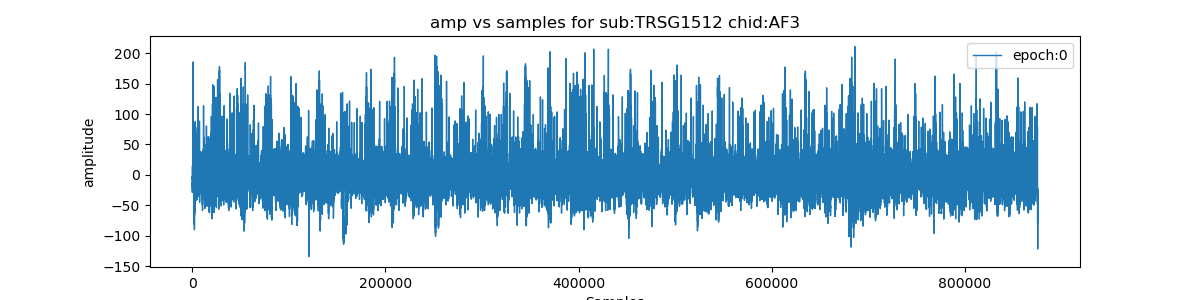

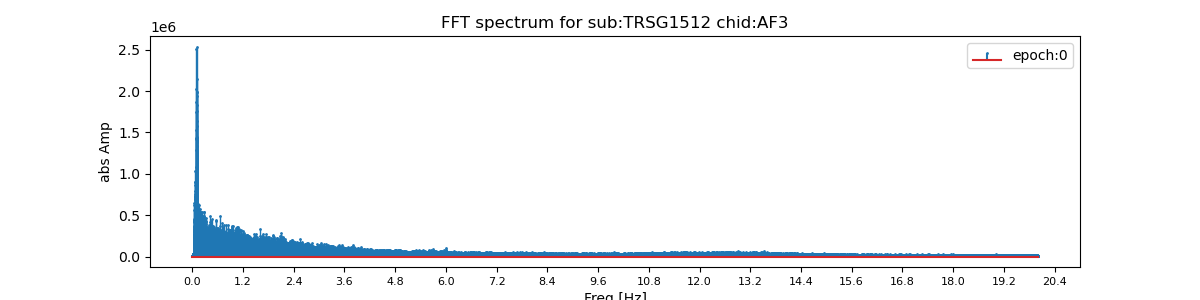

In [10]:
## plotting the data
chid=3
cf.showmeSummaryPlot(mat_data[:,chid-1],fs=np.squeeze(meta_data["fs"]),subjid=subjid,chname=meta_data["chanlocs"]["labels"][chid-1],freqlim=[0,20])

### 7a. computing ICA 
###### to get rid of blink artifacts if they are present

In [12]:
import FPVS_pycage as FPVS
importlib.reload(FPVS)

matfilepath = matfilepath.with_suffix(".npy")
metafilepath = metafilepath.with_suffix(".pkl")
ica, raw, ica_data, idx = FPVS.preprocessFPVSdata_performICA(matfilepath=matfilepath, metafilepath = metafilepath)

ica.fit(raw)
ica.plot_components(inst=raw)
ica.plot_sources(inst=raw)

Creating RawArray with float64 data, n_channels=70, n_times=875264
    Range : 0 ... 875263 =      0.000 ...  3418.996 secs
Ready.
length of dict: 70
Fitting ICA to data using 70 channels (please be patient, this may take a while)


C:\Users\Admin\anaconda_projects\FPVS Pypeline\FPVS_pycage.py:312: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Selecting by explained variance: 57 components
Fitting ICA took 63.2s.
Using EOG channel: Fp1
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upp

C:\Users\Admin\AppData\Local\Temp\ipykernel_24040\807782299.py:8: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Selecting by explained variance: 57 components
Fitting ICA took 59.2s.


ValueError: The following electrodes have overlapping positions, which causes problems during visualization:
EXG7, EXG8

In [ ]:
# np.load("D:\Goffaux lab\Data set\Python_CSVfiles\7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.npy")
# %matplotlib widgets


## 7.b Overlay ICA matrix

In [1]:
importlib.reload(FPVS)
FPVS.overlayICAondata(matfilepath,metafilepath,ica_data)


NameError: name 'importlib' is not defined

In [14]:
#select only 1 ICAmatrix
# rmidx = [0,2,3,5,6,9,11,13,15,16,17,18,19,20,21,23,24] # 24 looks dicey CHMA
# rmidx = [0, 3, 10, 17]

## 7.c Apply ICA data

In [15]:
importlib.reload(cf)
importlib.reload(FPVS)
mat_data, meta_data, metafilepath = FPVS.preprocessFPVSdata_applyICA(matfilepath, metafilepath, ica , raw, rmidx)

Removing ICA components: [0, 3, 10, 17]
Applying ICA to Raw instance
    Transforming to ICA space (57 components)
    Zeroing out 4 ICA components
    Projecting back using 70 PCA components
ICA performed, data saved as  D:\Goffaux lab\Data set\second expt\ica_filt6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels TRSG1512


## 7. Segmentation
##### 1. Find a way to get the time stamps DONE
##### 2. Convert sample to time and start cropping data.

In [16]:
importlib.reload(cf)
# matfilepath = Path("D:\Goffaux lab\Data set\\new_data\\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels 4_chan-select TRSG1512.npy")
# metafilepath = Path("D:\Goffaux lab\Data set\\new_data\\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels 4_chan-select TRSG1512.pkl")
# mat_data = np.load(matfilepath)
# meta_data = cf.loadMetadata(metafilepath)

errorflag = 0
fs = (meta_data["fs"])  # Hz
eventid  = np.array(meta_data["events"]["code"])
timestamps  = np.array(meta_data["events"]["latency"],dtype = float)
duration = 70 * fs
# if "45" in eventid:
#     print("present")

unq_eventid = np.unique(eventid)
mask = np.array([x.isnumeric() for x in unq_eventid])
unq_eventid = unq_eventid[mask]
unq_eventid = unq_eventid.astype(int)
unq_eventid.sort()
unq_eventid = unq_eventid.astype(str)

startcode = np.array([10, 45, 90, 135, 200, 210, 212, 214, 216, 218, 220, 222, 224],dtype = int)
# startcode = np.array([10,45,90,200,226,228,230,232],dtype = int)
startcode_ind = np.where(np.isin(unq_eventid.astype(int), startcode))[0]
startevents = unq_eventid[startcode_ind]
startevents.sort()

endcode = startcode.copy() + 1
endcode_ind = np.where(np.isin(unq_eventid.astype(int), endcode))[0]
endevents = unq_eventid[endcode_ind]
endevents.sort()

S0id = [None] * len(startevents)
Snid = [None] * len(endevents)

startendsample = [[None] for i in range(len(startevents))]
eventreps = np.zeros(len(startevents))
# print(startevents.shape)
alleventnos = 0
for eventno in range(len(startevents)):
    Ks = (fs * timestamps[[i for i, x in enumerate(eventid) if x == startevents[eventno]]])
    S0id[eventno] = Ks.astype(int)

    Ke = (fs * timestamps[[i for i, x in enumerate(eventid) if x == endevents[eventno]]])
    Snid[eventno] = Ke.astype(int)

    starts = np.array(S0id[eventno])
    stops = np.array(Snid[eventno])
    used_stops = np.zeros(len(stops), dtype=bool)

    # First: match starts to closest valid stops
    pairs = []
    for s in starts:
        diffs = stops - s
        # valid stops should be ~70s after start
        valid = np.where((diffs > 0) & (np.abs(diffs - duration) < fs))[0]
        if len(valid) > 0:
            idx = valid[0]
            pairs.append((int(s - 2 * fs), int(stops[idx])))
            used_stops[idx] = True
        else:
            # missing stop → infer
            pairs.append((int(s - 2 * fs), int(s + 68 * fs)))

    # Second: handle stops pairs that were never used (missing starts)
    for i, stop_used in enumerate(used_stops):
        if not stop_used:
            e = stops[i]
            pairs.append((int(e - 70 * fs), int(e)))
            
    pairs = cf.givemeUniqueTuples(pairs, tolerance=2 * fs)
    startendsample[(eventno)] = pairs
    eventreps[eventno] = len(pairs)

# for idx, pairs_i in enumerate(startendsample):
#     if len(pairs_i) not in [2, 5]:
#         print(f"Warning: Event {startevents[idx]} has {len(pairs_i)} reps")
#         errorflag = 1

# so far we have removed the obtained the time stamp, sample stamp and event code of all the stim that have been presented.
# I have then removed the time and sample stamp of all those events that are not relevant to the experiment's analysis like 21/22/50/55
# trimming the data points
nch = mat_data.shape[1]
nevents = (eventreps.sum()).astype(int)
ep_data =  np.zeros((17920, nch,nevents))
## add functionality that makes this compatible with all expts, not just this one ie. self calculating the 41 in this case
count = 0
eventrepdata = {}
startendsampid = np.zeros([nevents,2])
for eventno in range(len(startcode)):
    numrep = []
    for iterid in range(int(eventreps[eventno])):
        dsamp_start = startendsample[eventno][iterid][0]
        dsamp_end = startendsample[eventno][iterid][1]
        startendsampid[count,0] = dsamp_start
        startendsampid[count,1] = dsamp_end
        
        eventrep_dat = np.arange(dsamp_start, dsamp_end, dtype="int")
        # print("range:", dsamp_start, "-", dsamp_end, " length:", dsamp_end - dsamp_start)
        ep_data[:, :nch, count] = mat_data[eventrep_dat, :nch]
        numrep.append(count)
        count += 1
        # final data will have dimensions like so:(17920, 70, 41)
    print("Event label being split: ",startevents[eventno]," number of reps: ", len(numrep))
    eventrepdata[str(startevents[eventno])] = np.array(numrep)

if errorflag == 0:
    mat_data = ep_data.copy()
    meta_data["eventrepid"] = eventrepdata

meta_data = cf.updatemetadataHistory(meta_data,"7_ep")
metafilepath = metafilepath.with_name("7_ep " + metafilepath.stem)
matfilepath = matfilepath.with_name("7_ep " + matfilepath.stem)

matfilepath = matfilepath.with_suffix(".npy")
metafilepath = metafilepath.with_suffix(".pkl")
np.save(matfilepath, mat_data)
cf.saveMetadata(meta_data,metafilepath)

Event label being split:  10  number of reps:  3
Event label being split:  200  number of reps:  3
Event label being split:  90  number of reps:  3


IndexError: index 3 is out of bounds for axis 0 with size 3

In [17]:
print(unq_eventid)

['10' '11' '21' '22' '23' '50' '54' '55' '60' '61' '62' '90' '91' '200'
 '201' '226' '227' '228' '229' '230' '231' '232' '233']


In [ ]:
## Plotting the Spectrogram
importlib.reload(cf)
subjid = metafilepath.stem.split()[-1]
chid = 2
epochid = 0
titlestr = f" STFT Spectrogram for {subjid} {meta_data["chanlocs"]["labels"][chid]} in epoch {epochid}"
cf.showmeSTFTSpectrogram(mat_data[:,:,epochid],chid = chid , titlestr = titlestr)

In [ ]:
importlib.reload(cf)
%matplotlib widget

chid = 28
subjid = metafilepath.stem.split()[-1]
epochid = 14
titlestr = f" MW Spectrogram for {subjid} {meta_data["chanlocs"]["labels"][chid]} for epoch {epochid}"
cf.showmeMWSpectrogram(mat_data,chid = chid, epochid = epochid , titlestr = titlestr)
#Modify this line

In [ ]:
%matplotlib widget

chid=28
epochid=14
fs = meta_data["fs"]
subjid = metafilepath.stem.split()[-1]
chname = meta_data["chanlocs"]["labels"][chid]
cf.showmeSummaryPlot(ep_data[:,chid,epochid],fs=fs,subjid=subjid,chname=chname,epochid=epochid)

## 7.C interpolation
to clean up noisy channels through averaging the activations of neighbouring channels
1. no more than 5% of channels should be interpolation 
2. no channel should be used twice for interpolation
3. no interpolated channel should be used for interpolation

In [ ]:
importlib.reload(cf)
%matplotlib widget
matfilepath = matfilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')
print(matfilepath)
mat_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)
cf.showmeSignalUI(mat_data, meta_data,ylim=[-300,500])


In [ ]:
## Doing the actual interpolation 
interp_chnames = ['P1','P3','PO3']
badchid = ['Fp1','CP6','I2']
print(labels)

In [ ]:
importlib.reload(FPVS)
labels = (meta_data["chanlocs"]["labels"])
interp_chids = np.where(np.isin(labels, interp_chnames))[0]

# interpolation
badch = np.union1d(interp_chnames, badchid) 
interp_specs = {}
for i in range(len(interp_chnames)):
    srt_idx, srt_labels = cf.givemeNNearestNeighbour(meta_data, interp_chids[i])
    srtd_idx = np.where(~np.isin(srt_labels, badch))[0]
    srtd_idx = srtd_idx[:3]
    badch = np.append(badch, srt_labels[srtd_idx])
    mat_data[:, interp_chids[i], :] = np.mean(mat_data[:, srtd_idx, :], axis=1)
    new_entry = {interp_chnames[i] : srt_labels[srtd_idx]}
    interp_specs.update(new_entry)
    print(interp_chnames[i], "is interpolated using ", [labels[i] for i in srtd_idx])

meta_data["interpolation"] = interp_specs
extn_str = f"{len(interp_chnames)}_interp "

metafilepath = matfilepath.with_name(extn_str + metafilepath.stem)
meta_data = cf.updatemetadataHistory(meta_data,extn_str)
cf.saveMetadata(meta_data,metafilepath)

matfilepath = matfilepath.with_name(extn_str + matfilepath.stem)
np.save(matfilepath, mat_data)
print("channels are interpolated and saved as ", metafilepath)# interpolation and referencing merged into one function for simplicity, if need arises, we can split them into two

## 8. Referencing

In [ ]:
#referencing
# matfilepath = Path("D:\Goffaux lab\Data set\Python_CSVfiles\\3_interp 7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels BEFR2711.npy")
# metafilepath = matfilepath.with_suffix('.pkl')

# mat_data = np.load(matfilepath)
# meta_data = cf.loadMetadata(metafilepath)
if 'badch' not in globals():
    badch = None
    
labels = meta_data["chanlocs"]["labels"]
goodchids = np.where(~np.isin(labels, badch))[0]
glreference = np.mean(mat_data[:, goodchids, :], axis=1,keepdims=True)
mat_data = mat_data - glreference

meta_data["ref_chids"] = goodchids

matfilepath = matfilepath.with_name("8_ref " + matfilepath.stem)
metafilepath = metafilepath.with_name("8_ref " + metafilepath.stem)
meta_data = cf.updatemetadataHistory(meta_data,"8_ref")
cf.saveMetadata(meta_data,metafilepath)
np.save(matfilepath, mat_data)
print("data is referenced and saved as ", metafilepath)

In [ ]:
print(goodchids)
print(meta_data["chanlocs"]["labels"])
print(labels)
print(len(meta_data["chanlocs"]["labels"]))
print(badch)

## 9. Segmentation with exact number of bins, one file per condition
1. I already have events with the same number of bins
2. If segment length is 16213 bins then either the segment length or sampling rate cant be 64 and 256 respectively. (plus 16213 is an oddly specific number) 

In [ ]:
# print(meta_data["eventrepid"])

## 9.5. Splitting data based on condition/events (T/D/L/R) 


In [ ]:
## This needs to be changed according to the expt, What can be done is 

# matfilepath = Path("D:\Goffaux lab\Data set\Python_CSVfiles\\8_ref 3_interp 7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels BEFR2711.npy")
# metafilepath = matfilepath.with_suffix('.pkl')

# mat_data = np.load(matfilepath)
# meta_data = cf.loadMetadata(metafilepath)

mergekeyflag = True #default value is that some events need to be merged. if this is set to 0 then no event is merged
mergekeys ={
    "TOP": [210,212],
    "BOTTOM": [214,216],
    "RIGHT": [218,220],
    "LEFT": [222,224]
}
print(metafilepath.parent)
subjid=metafilepath.stem.split()[-1]

if len(subjid) !=8: #Prevents taking 'lw6' as the subject id as we know that subject id is usually 8 characters long
    subjid = strings[-2]

#merging events
slices = meta_data["eventrepid"]
print("event ids in this file are: ", slices.keys())
if mergekeyflag == True:
    keys = mergekeys.keys()
    delkeys = []
    for i in keys:
        print(i)
        a = slices[str(mergekeys[i][0])]
        b = slices[str(mergekeys[i][1])]
        ab = np.union1d(a,b)
        slices[i] = ab
        delkeys.append(str(mergekeys[i][0]))
        delkeys.append(str(mergekeys[i][1]))

    list(map(slices.pop,delkeys))
    
meta_data["eventrepid"] = slices
for label in slices.keys():
    start = slices[label][0]
    end = slices[label][-1]
    # print(start,end)
    data = mat_data[:, :, start:end+1]
    # print(start:end)
    filepath = metafilepath.parent / f"{label} {subjid}.npy"
    np.save(filepath, data)
    print(f"event {label}: {start}:{end} for {data.shape[2]} reps")    
    print(f"Saved: {filepath}")

metafilepath = metafilepath.with_name("split " + metafilepath.stem)
cf.saveMetadata(meta_data,metafilepath)

## Merging data files based on events (postprocessing step 1)

In [ ]:
%reset -f
import scipy.io as sci
from pathlib import Path
import h5py
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
import math
from collections import Counter
import importlib
import cust_funcs as cf
importlib.reload(cf)
import ipympl


event_label = "200"
print(f" the event you're running this script for is {event_label}")
files = sorted(folderpath.glob(f"{event_label}*.npy"))
print(*files, sep='\n')
files = files[:]
print("\n")
data_list = []
subj_merged = []

for file in files:
    subjid = file.stem.split()[-1]
    if len(subjid) != 8:  # Prevents taking '{subjid} MERGED' file as a file
        continue

    data = np.load(file)  # loads array saved earlier
    data_list.append(data)
    subj_merged.append(subjid)

mat_data = np.concatenate(data_list, axis=2)
meta_data = {
    "event_label": event_label,
    "subjids": subj_merged,
    "shape": mat_data.shape,
    "size": mat_data.size,
    "fs" : 256,
    "history" :{}
}

matfilepath = folderpath / f"{event_label} MERGED.npy"
metafilepath = folderpath / f"{event_label} MERGED.pkl"
np.save(matfilepath, mat_data)
cf.saveMetadata(meta_data,metafilepath)
print("data is merged based on epochs, saved as: ",matfilepath)

## 10. Fourier transform

In [ ]:
fs  = meta_data["fs"]
freq_min = 0
freq_max = 50
meta_data["freq_range"] = [freq_min, freq_max]

freqs = np.fft.fftfreq(mat_data.shape[0], 1 / fs)
idx = np.where((freqs >= freq_min) & (freqs <= freq_max))[0]
freq_idx = freqs[idx]
FFT_data = np.zeros([len(freq_idx), mat_data.shape[1], mat_data.shape[2]])

for chid in range(mat_data.shape[1]):
    for epochid in range(mat_data.shape[2]):
        FFT_signal = np.abs(np.fft.fft((mat_data[:, chid, epochid])))
        FFT_data[:, chid, epochid] = FFT_signal[idx]

mat_data = FFT_data.copy()
del FFT_data
matfilepath = matfilepath.with_name("10_FFT " + matfilepath.stem)

meta_data = cf.updatemetadataHistory(meta_data,"10_FFT")
metafilepath = matfilepath.with_name("10_FFT " + metafilepath.stem)
cf.saveMetadata(meta_data,metafilepath)


np.save(matfilepath, mat_data)

print("FFT data is saved as ", matfilepath)
# cf.showmeSignal(mat_data[:,chid,epochid],freq_idx)

## 11. Average within trials

In [ ]:
avg_data = np.mean(mat_data, axis=2)
mat_data = avg_data.copy()

matfilepath = matfilepath.with_name("11_avg " + matfilepath.stem)
np.save(matfilepath, mat_data)

meta_data = cf.updatemetadataHistory(meta_data,"11_avg")
metafilepath = metafilepath.with_name(matfilepath)
cf.saveMetadata(meta_data,metafilepath)

print("averaged data is saved as ", matfilepath)

In [ ]:
#ploting the actual data data
%matplotlib widget
chid = 1
epochid = 1
cf.showmeSignal(mat_data,chid = chid)
print(len(idx))

## 12. chunks 
take out chunks from the frequencies of interest. Here, i am assuming a chunking window of .4 Hz centred at frequency of interest. This isnt final, but it is different from Talia's doc

In [ ]:
freq_res = (freq_max - freq_min) / mat_data.shape[0]
window_width = .4
chunkWidth = window_width + freq_res
meta_data["chunk_width"] = chunkWidth
harmonics = np.arange(1.2, 50, 1.2)
harmonics = harmonics[harmonics <= 50]
chunk_data = np.zeros((int(np.floor(chunkWidth / freq_res)), mat_data.shape[1], len(harmonics)))
idx = np.where((freqs >= freq_min) & (freqs <= freq_max))[0]
freq_idx = freqs[idx]

for chid in range(mat_data.shape[1]):
    for fhid in range(len(harmonics)):
        idx = np.where(
            (freq_idx > (harmonics[fhid] - chunkWidth / 2)) & (freq_idx <= (harmonics[fhid] + chunkWidth / 2)))[0]
        # print(freq_idx[idx])
        chunk_data[:, chid, fhid] = mat_data[idx, chid]

mat_data = chunk_data.copy()
matfilepath = matfilepath.with_name("12_chunk " + matfilepath.stem)
np.save(matfilepath, mat_data)

meta_data = cf.updatemetadataHistory(meta_data,"12_chunk")
metafilepath = metafilepath.with_name("12_chunk " + metafilepath.stem)
cf.saveMetadata(meta_data,metafilepath)


print("data is chunked at frequencies of interest and saved as ", matfilepath)

## 13. Select chunks for harmonics
Add functionality to take only those values that are significantly greater than the baseline

In [ ]:
bl_chunks = np.arange(4, mat_data.shape[2], 5)
bl_chunkmask = np.zeros(mat_data.shape[2], dtype=bool)
bl_chunkmask[bl_chunks] = "True"
odd_chunkmask = ~bl_chunkmask

bl_data = mat_data[:, :, bl_chunkmask]
odd_data = mat_data[:, :, odd_chunkmask]

# Select the first 3 for baseline and 12 chunks for oddball
blchunkselect = 3
oddchunkselect = 3
bl_data = bl_data[:, :, 0:blchunkselect]
odd_data = odd_data[:, :, 0:oddchunkselect]

meta_data_bl = meta_data.copy()
meta_data_odd = meta_data.copy()

meta_data_bl["nChunks"] = blchunkselect
meta_data_bl["eventType"] = "Baseline"

meta_data_odd["nChunks"] = oddchunkselect
meta_data_odd["eventType"] = "Oddball"

meta_data_bl = cf.updatemetadataHistory(meta_data_bl,"13_baseline")
meta_data_odd = cf.updatemetadataHistory(meta_data_odd, "13_oddball")
blmatfilepath = matfilepath.with_name("13_baseline " + matfilepath.stem)
np.save(blmatfilepath, bl_data)
blmetadatafilepath = metafilepath.with_name("13_baseline " + metafilepath.stem)
np.save(blmetadatafilepath, meta_data_bl)

print("baseline data saved, size of the data in ",blmatfilepath)

oddmatfilepath = matfilepath.with_name("13_oddball " + matfilepath.stem)
np.save(oddmatfilepath, odd_data)
oddmetafilepath = metafilepath.with_name("13_oddball " + metafilepath.stem)
np.save(oddmetafilepath, meta_data_odd)
print("oddball data saved, size of the data in ",oddmatfilepath)

## 14. Sum of harmonics

In [ ]:
bl_data = np.sum(bl_data, axis=2)
odd_data = np.sum(odd_data, axis=2)

blmatfilepath = blmatfilepath.with_name("14_sum " + blmatfilepath.stem)
meta_data_bl = cf.updatemetadataHistory(meta_data_bl,"14_sum")
blmetadatafilepath = blmetadatafilepath.with_name("14_sum " + blmetadatafilepath.stem)
np.save(blmetadatafilepath, meta_data_bl)
np.save(blmatfilepath, bl_data)
print("Harmonics of bl_data is added and the new shape is:", bl_data.shape)

oddmatfilepath = oddmatfilepath.with_name("14_sum " + oddmatfilepath.stem)
oddmetafilepath = oddmetafilepath.with_name("14_sum " + oddmetafilepath.stem)
np.save(oddmatfilepath, odd_data)
meta_data_odd = cf.updatemetadataHistory(meta_data_odd, "14_sum")
np.save(oddmetafilepath, meta_data_odd)
print("Harmonics of odd_data is added and the new shape is:", odd_data.shape)

In [ ]:
print(mat_data.shape)

## 15. SNR and baseline correction

In [ ]:
mask =np.ones(bl_data.shape[0],dtype = bool)
mask[bl_data.shape[0]//2] = False

blcorrbl_data = np.mean(bl_data[mask,:],axis=0)
print(blcorrbl_data.shape)
bl_data_corr = bl_data - blcorrbl_data
print(bl_data_corr.shape)


blcorrodd_data = np.mean(odd_data[mask,:],axis=0)
print(blcorrodd_data.shape)
odd_data_corr = odd_data - blcorrodd_data
print(odd_data_corr.shape)

## TopoMaps of chunks 

In [ ]:
# bl_data = np.load(blmatfilepath)
# odd_data = np.load(oddmatfilepath)
importlib.reload(cf)
event_label = "200"
# print(bl_data.shape)
titlestr = f"{event_label}-Baseline"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(bl_data[freqid,:],meta_data,titlestr)


In [ ]:
importlib.reload(cf)
# print(bl_data.shape)
titlestr = f"{event_label}-Baseline corrected"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(bl_data_corr[freqid,:],meta_data,titlestr)


In [ ]:
importlib.reload(cf)
# print(bl_data.shape)
titlestr = f"{event_label}-Oddball"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(odd_data[freqid,:],meta_data,titlestr)

In [ ]:
importlib.reload(cf)
# print(bl_data.shape)
titlestr = f"{event_label}-Oddball corrected"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],meta_data)
cf.showme3DTopomap(odd_data_corr[freqid,:],meta_data,titlestr)

In [ ]:
%matplotlib widget
importlib.reload(cf)
print(bl_data.shape[0]//2-1)
titlestr = [f" amplitude vs frequency at chunking window for {event_label}-baseline"]
cf.showmeSignal(bl_data,titlestr=titlestr)


In [ ]:
%matplotlib widget
importlib.reload(cf)
print(odd_data.shape[0]//2-1)
# chid = 0
chid +=1
print(chid)
cf.showmeSignal(bl_data_corr)


In [ ]:
cf.showmeSignal(odd_data)


In [ ]:
cf.showmeSignal(odd_data_corr)


In [ ]:
%matplotlib widget 
importlib.reload(cf)
# print(bl_data.shape)
event_label = "200"
titlestr = f"{event_label}-Baseline "
%matplotlib widget
cf.showme2DTopomap(bl_data[bl_data.shape[0]//2,:],meta_data,titlestr=titlestr)

In [ ]:
%matplotlib widget 
importlib.reload(cf)
# print(bl_data.shape)
event_label = "200"
titlestr = f"{event_label}-Baseline 'corrected'"
%matplotlib widget
cf.showme2DTopomap(bl_data_corr[bl_data.shape[0]//2,:],meta_data,titlestr=titlestr)

## "Scrap code that might be usefull in the future" notebook 

In [ ]:
# PLot/make skull object
import trimesh 
import os
print(os.listdir())
mesh = trimesh.load('skull.obj')
vertices = mesh.vertices
faces = mesh.faces

# Center
vertices = vertices - vertices.mean(axis=0)

# Scale to unit sphere
vertices = vertices / np.max(np.linalg.norm(vertices, axis=1))
scale_factor = 2.0  # make skull 2x bigger

vertices = vertices * scale_factor

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Mesh3d(
    x=vertices[:, 0],
    y=vertices[:, 1],
    z=vertices[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    color='lightgray',
    opacity=0.6
))

fig.update_layout(
    scene=dict(aspectmode='data'),
    title='Skull Mesh'   
)


fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    )
)

fig.show()

## An attempt at saving the metadata as a .json file

In [ ]:
import json
import numpy as np

# 1. Define the encoder that converts any nested numpy array to a list
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        # Handle numpy scalars (like np.int64 or np.float32) too
        if isinstance(obj, np.generic):
            return obj.item()
        return super().default(obj)

# 2. Use the 'cls' parameter to apply it
with open('meta_data.json', 'w') as f:
    json.dump(meta_data["header"], f, indent=4, cls=NumpyEncoder)



In [ ]:
import json
import numpy as np

def simplify_mat(data):
    """
    Recursively converts nested numpy arrays/MATLAB structs 
    into clean Python lists and dictionaries.
    """
    # 1. Handle Numpy Arrays
    if isinstance(data, np.ndarray):
        # If it's an empty array
        if data.size == 0:
            return []
        # If it's a "Struct" array (has fields)
        if data.dtype.names is not None:
            return {name: simplify_mat(data[name][0, 0]) for name in data.dtype.names}
        # If it's a single value wrapped in an array, unwrap it
        if data.size == 1:
            val = data.item()
            return simplify_mat(val)
        # Otherwise, convert the whole array to a list
        return [simplify_mat(i) for i in data]
    
    # 2. Handle standard Python collections
    elif isinstance(data, dict):
        return {k: simplify_mat(v) for k, v in data.items()}
    elif isinstance(data, (list, tuple)):
        return [simplify_mat(i) for i in data]
    
    # 3. Handle specific types like bytes from MATLAB strings
    elif isinstance(data, bytes):
        return data.decode('utf-8')
    
    return data

# --- APPLICATION ---

# 1. Clean the header data
structured_data = simplify_mat(meta_data["header"])

# 2. Save to JSON with a fallback for numpy scalars
with open('meta_data_clean.json', 'w') as f:
    json.dump(
        structured_data, 
        f, 
        indent=4, 
        default=lambda obj: obj.item() if hasattr(obj, 'item') else str(obj)
    )

print("Success! File saved.")



In [ ]:
import json
import numpy as np

def simplify_mat(data):
    # 1. Handle Numpy Arrays
    if isinstance(data, np.ndarray):
        if data.size == 0:
            return []
        
        # If it's a MATLAB struct (it has field names)
        if data.dtype.names is not None:
            # If it's an array of structs (like events), process each one
            if data.size > 1 or (data.ndim > 0 and data.shape[0] > 1):
                return [simplify_mat(item) for item in data.ravel()]
            # If it's just one struct, turn it into a dict
            return {name: simplify_mat(data[name][0]) for name in data.dtype.names}
        
        # For numeric/string arrays, only unwrap if it's truly a single scalar
        # Otherwise, keep it as a list (to preserve all 68 electrodes, etc.)
        if data.size == 1:
            return simplify_mat(data.item())
        
        return [simplify_mat(i) for i in data]

    # 2. Handle nested collections
    elif isinstance(data, dict):
        return {k: simplify_mat(v) for k, v in data.items()}
    elif isinstance(data, (list, tuple)):
        return [simplify_mat(i) for i in data]
    elif isinstance(data, bytes):
        return data.decode('utf-8')
    
    return data

# --- EXECUTION ---
structured_data = simplify_mat(meta_data["header"])

with open('meta_data_full.json', 'w') as f:
    json.dump(
        structured_data, 
        f, 
        indent=4, 
        default=lambda obj: obj.item() if hasattr(obj, 'item') else str(obj)
    )

print("Success! File saved.")